Ingest and clean cart level data from Vori. This report was extracted from the UI Reports > Item Sales > Underlying data

In [1]:
import pandas as pd
import numpy as numpy
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
os.getcwd()

'/home/tiburon/pCloudDrive/pCloud Backup/mofongo-HP-EliteBook-840-G8-Notebook-PC/pCloud_docs/ghfc/merch/merch_analysis_git/cart_analysis'

In [5]:
df = pd.read_csv('./Items with cost(2).csv')

/tmp/ipykernel_9108/1483129609.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./Items with cost(2).csv')


In [6]:
#42 columns is a lot
df.shape

(73951, 42)

In [8]:
df.columns.sort_values()

Index(['% Items with cost', 'Active Vendor', 'Barcode', 'Bottle Deposits',
       'Brand', 'Cashier', 'Cost of Goods Sold', 'Department',
       'Discount and Rewards', 'Each Cost', 'Ebt Enabled', 'Ebt Tax Exempted',
       'Is Type 2', 'Items Total', 'Lane', 'Line Total', 'Line Type',
       'Loyalty Status', 'Manual Item', 'Net Margin %', 'Order Date',
       'Order ID', 'Product Cost Source', 'Product Cost Status', 'Product ID',
       'Product Is Tippable', 'Product Name', 'Promotion Amount',
       'Promotion Flag', 'Quantity', 'Retail Price', 'Sales', 'Shopper Phone',
       'Sold by Weight', 'Store Name', 'Sub-Department', 'Tax Collected',
       'Taxable Flag', 'Weight', 'Wic Adjusted Price', 'Wic Adjustment',
       'Wic Enabled'],
      dtype='object')

In [14]:
df['Order ID'].describe()

count             73951
unique             7407
top       GHA1763918810
freq                 78
Name: Order ID, dtype: object

In [14]:
obj = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73951 entries, 0 to 73950
Data columns (total 42 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   % Items with cost     73951 non-null  float64
 1   Order ID              73951 non-null  object 
 2   Order Date            73951 non-null  object 
 3   Lane                  73951 non-null  object 
 4   Cashier               73951 non-null  object 
 5   Shopper Phone         45 non-null     float64
 6   Loyalty Status        73951 non-null  object 
 7   Line Type             73951 non-null  object 
 8   Sub-Department        73951 non-null  object 
 9   Product ID            73951 non-null  float64
 10  Product Name          73951 non-null  object 
 11  Brand                 39189 non-null  object 
 12  Barcode               73951 non-null  object 
 13  Manual Item           73951 non-null  bool   
 14  Sold by Weight        73951 non-null  bool   
 15  Ebt Enabled        

In [4]:
#print only the float columns
df.select_dtypes(include=['float64']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73951 entries, 0 to 73950
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   % Items with cost     73951 non-null  float64
 1   Shopper Phone         45 non-null     float64
 2   Product ID            73951 non-null  float64
 3   Each Cost             69752 non-null  float64
 4   Retail Price          73951 non-null  float64
 5   Wic Adjusted Price    0 non-null      float64
 6   Quantity              73951 non-null  float64
 7   Weight                25814 non-null  float64
 8   Promotion Amount      73951 non-null  float64
 9   Items Total           73951 non-null  float64
 10  Bottle Deposits       73951 non-null  float64
 11  Discount and Rewards  73951 non-null  float64
 12  Wic Adjustment        0 non-null      float64
 13  Sales                 73951 non-null  float64
 14  Cost of Goods Sold    69752 non-null  float64
 15  Ebt Tax Exempted   

In [8]:
#attempt to remove spoilage-related order_id 
df = df.assign(order_dt = pd.to_datetime(df['Order Date'], errors = 'coerce'))

/tmp/ipykernel_9108/3218756571.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = df.assign(order_dt = pd.to_datetime(df['Order Date'], errors = 'coerce'))


In [ ]:
#confirm it works
df.select_dtypes(include=['datetime64'])

,order_dt
0,2025-12-18 16:17:00
1,2025-12-06 12:25:00
2,2025-11-24 17:33:00
3,2025-11-23 16:10:00
4,2025-12-03 13:10:00
...,...
73946,2025-10-19 11:02:00
73947,2025-10-19 15:56:00
73948,2025-11-20 17:19:00
73949,2025-12-02 17:10:00


The first step is to identify spoilage and attempt to remove it. Spoilage is expected to be recorded at 100% of the price or cost. Discounted items are OK.

In [16]:
#Order ID is likely on the entire cart, so it's a 1:many on the underlying items
#I'm isolating cases where the ENTIRE 'Order Id' - not just the component items - have negative total value, which implies that the entire cart was comprised of spoilage
sales_sum_df = df.groupby(['order_dt','Order ID']).agg(sales_sum=('Sales','sum')).query('sales_sum <0').reset_index()

In [12]:
#counting the # of negative sales transactions (presumably all spoilage)
sales_sum_df.groupby(sales_sum_df['order_dt'].dt.date).agg(count=('Order ID','nunique')).sort_values('order_dt').head()

,count
order_dt,
2025-10-01,2
2025-10-05,2
2025-10-07,1
2025-10-08,2
2025-10-09,1


In [17]:
#isolate a dataframe of orders that are negative
sales_sum_df1 = df.groupby(['Order ID']).agg(sales_sum=('Sales','sum'),discount_sum=('Discount and Rewards','sum')).query('sales_sum <0').reset_index()

In [18]:
sales_sum_df1.sample(5)

,Order ID,sales_sum,discount_sum
28,GHA1763913047,-2.25,0.0
10,GHA1760479989,-9.35,0.0
6,GHA1760043257,-18.20,0.0
47,GHB1764185200,-8.46,0.0
21,GHA1762814255,-3.37,0.0


In [19]:
#investigate the relationship between negative sales (per Order ID) and 'Discount and Rewards'; ALL negative carts are refunds
sales_sum_df2 = df.query("`Line Type` != 'Refund'").groupby(['Order ID']).agg(sales_sum=('Sales','sum'),discount_sum=('Discount and Rewards','sum')).query('sales_sum <0').reset_index()

<Axes: title={'center': 'distribution of discounts'}, ylabel='Frequency'>

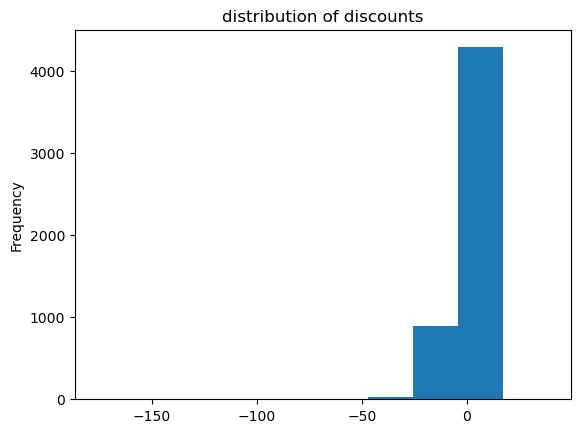

In [20]:
#identify spoilage transactions (all 100% discounted)
df.query("`Discount and Rewards` != 0")['Discount and Rewards'].plot(kind = 'hist', bins = 10, title='distribution of discounts')

In [21]:
#attempt to value all positive value carts
sales_sum_df_pos = df.groupby(['order_dt','Order ID']).agg(sales_sum=('Sales','sum')).query('sales_sum >0').reset_index()

In [22]:
sales_sum_df_pos.describe()

,order_dt,sales_sum
count,6872,6872.000000
mean,2025-11-10 05:22:14.537252608,50.988702
min,2025-10-01 12:31:00,0.010000
25%,2025-10-20 20:12:15,16.557500
50%,2025-11-09 16:46:30,39.000000
75%,2025-11-30 14:49:45,69.882500
max,2025-12-21 12:47:00,483.610000
std,NaN,47.701660


In [ ]:
sales_sum_df_pos.sample(5)

,order_dt,Order ID,sales_sum
1955,2025-10-24 14:59:00,GHA1761332392,7.72
748,2025-10-09 15:07:00,GHA1760036831,79.69
6353,2025-12-14 15:03:00,GHB1765742631,23.13
134,2025-10-02 18:51:00,GHA1759445495,124.18
4108,2025-11-16 17:17:00,GHA1763331468,27.51


In [23]:
agg_sales_trans = sales_sum_df_pos.groupby([sales_sum_df_pos['order_dt'].dt.normalize()]).agg(avg_basket=('sales_sum','mean'),num_trans=('Order ID','nunique')).reset_index()

<Axes: title={'center': 'Average Basket Value Over Time'}, xlabel='order_dt'>

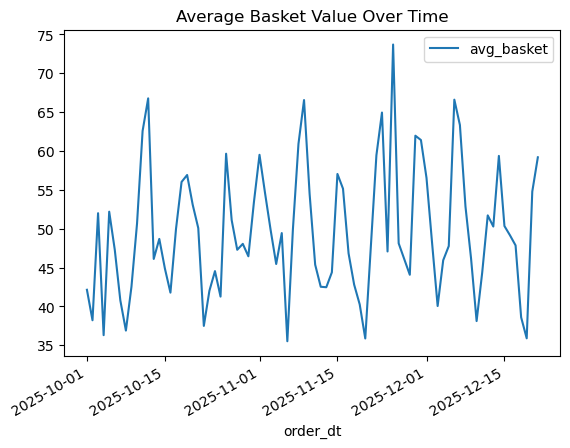

In [24]:
#time series of average basket value by order_dt
agg_sales_trans.plot(kind='line', x='order_dt', y='avg_basket', title='Average Basket Value Over Time')

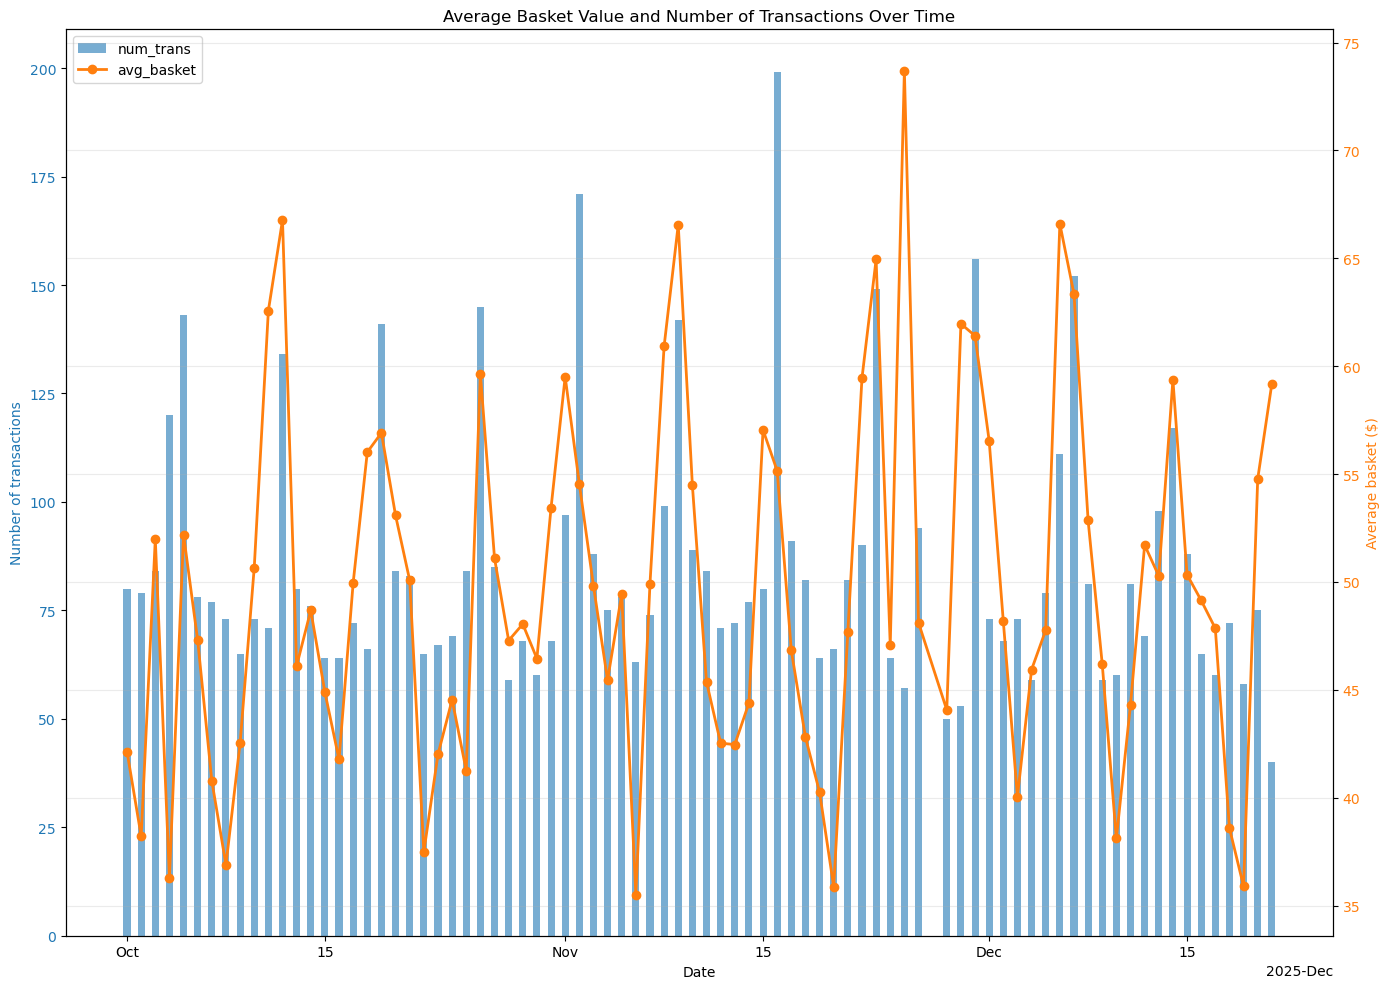

In [25]:
import matplotlib.dates as mdates

# ensure agg_sales_trans exists and order_dt is datetime
agg_sales_trans['order_dt'] = pd.to_datetime(agg_sales_trans['order_dt'])

fig, ax1 = plt.subplots(figsize=(14,10))

# bar plot: number of transactions (vertical bars)
ax1.bar(agg_sales_trans['order_dt'], agg_sales_trans['num_trans'],
        width=0.5, alpha=0.6, color='C0', label='num_trans')
ax1.set_ylabel('Number of transactions', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# format x-axis nicely for dates
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax1.xaxis.get_major_locator()))
ax1.set_xlabel('Date')

# line plot on secondary y-axis: average basket value
ax2 = ax1.twinx()
ax2.plot(agg_sales_trans['order_dt'], agg_sales_trans['avg_basket'],
         marker='o', color='C1', linewidth=2, label='avg_basket')
ax2.set_ylabel('Average basket ($)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

# combined legend and layout
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.title('Average Basket Value and Number of Transactions Over Time')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Recreate the above plot but partition by day of week, as there appears to be strong seasonality

In [24]:
cols = ['Barcode','Brand','Department','Items Total','Order Date',
'Product ID','Quantity','Sub-Department','Order ID']
df2 = df.loc[:,cols]
df2.columns = [i.replace(' ','_').lower() for i in cols]

In [ ]:
#df2['order_date'].to_dateteime(format="%a",%M %d, %Y, %h:%m %p)
try:
    df2['order_date2'] = pd.to_datetime(df2['order_date'],errors='coerce')
except ValueError as e:
    print(e)

/tmp/ipykernel_145305/1672676200.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['order_date2'] = pd.to_datetime(df2['order_date'],errors='coerce')


In [95]:
first = df2.groupby([df2['order_date2'].dt.normalize()])['order_id'].nunique().reset_index()


In [96]:
first.head()

,order_date2,order_id
0,2025-10-01,96
1,2025-10-02,85
2,2025-10-03,87
3,2025-10-04,126
4,2025-10-05,156


In [104]:
first_gb.index.name

'month'

In [110]:
#measure the average number of carts by day of week and month-year
first_gb = first.groupby([first['order_date2'].dt.month,first['order_date2'].dt.dayofweek])['order_id'].mean()
first_gb.index.names = ['month', 'dayofweek']
first_gb = first_gb.reset_index()

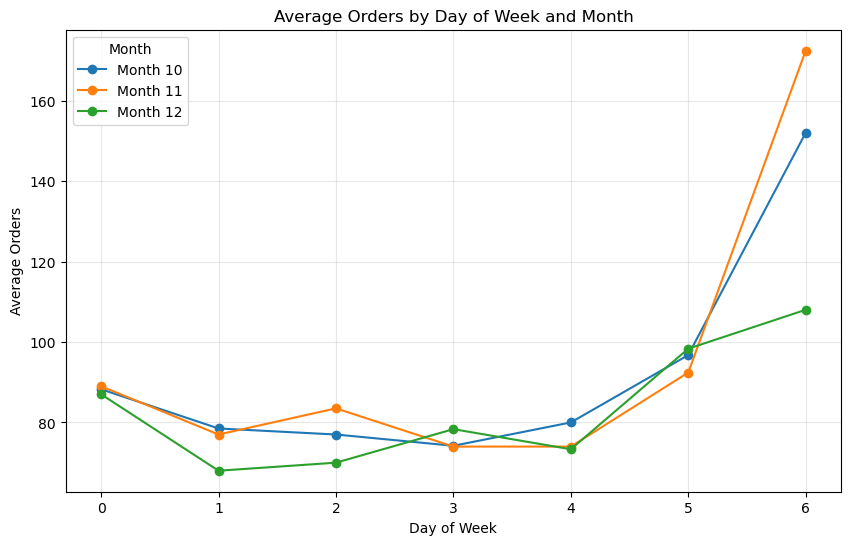

In [113]:
pivot_data = first_gb.pivot(index='dayofweek', columns='month', values='order_id')

plt.figure(figsize=(10, 6))
pivot_data.plot(ax=plt.gca(), marker='o')

plt.xlabel('Day of Week')
plt.ylabel('Average Orders')
plt.title('Average Orders by Day of Week and Month')
plt.legend(title='Month', labels=[f'Month {int(m)}' for m in pivot_data.columns])
plt.grid(True, alpha=0.3)
plt.show()

In [1]:
#in order to get context, calc the mean value of each basket... and afterwards a distribution